<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/processreportsandunits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit-safe process reporting and JSON export with NeqSim

This tutorial builds a compact gas-processing train, generates machine-readable equipment
reports in three unit systems, and validates both the process physics and the JSON payload.

**Learning objectives**

- assemble a valve, separator, compressor, and aftercooler in a `ProcessSystem`;
- verify total, component, and energy closure before reporting;
- generate and parse current NeqSim equipment-report JSON;
- switch report units without changing the thermodynamic state;
- validate field, default, and SI conversions independently; and
- design robust downstream checks for partial equipment schemas.

## Engineering question and boundary

A synthetic rich gas arrives at 40°C, 70 bara, and 20,000 kg/h. It is let down to 25 bara,
separated, recompressed to 70 bara, and cooled to 35°C. Can the simulation produce a
deterministic report that remains numerically consistent when its presentation units change?

All pressures are absolute. Component inputs are mole fractions. Energy rates are W and mass
rates are kg/h unless a report explicitly labels another unit. This is an educational
steady-state case, not a certified custody-transfer or equipment-design report.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Model and API choices

The fluid uses the Soave–Redlich–Kwong equation of state, database binary interaction
parameters, and multiphase stability checking. The public synthetic composition is rich
enough to form hydrocarbon liquid after isenthalpic pressure reduction.

`ProcessSystem` keeps the equipment composable. `Report.generateJsonReport()` produces an
equipment-status snapshot, while `Units` controls the report presentation profile. Unit
selection is global in the current Java API, so the notebook restores NeqSim's default unit
profile in a `finally` block. Production services should also serialize access to global
unit changes or isolate report generation per worker.

In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Report = jneqsim.process.util.report.Report
Units = jneqsim.util.unit.Units

FEED_COMPOSITION = {
    "nitrogen": 0.005,
    "CO2": 0.005,
    "methane": 0.700,
    "ethane": 0.100,
    "propane": 0.080,
    "n-butane": 0.050,
    "n-pentane": 0.030,
    "n-hexane": 0.020,
    "n-heptane": 0.010,
}
BASE_FEED_KG_H = 20_000.0
FEED_TEMPERATURE_C = 40.0
FEED_PRESSURE_BARA = 70.0
SEPARATOR_PRESSURE_BARA = 25.0
EXPORT_PRESSURE_BARA = 70.0
AFTERCOOLER_TEMPERATURE_C = 35.0
COMPRESSOR_EFFICIENCY = 0.75

## Reproducible process construction

Every case creates new thermodynamic and process objects. This prevents a sensitivity run
from inheriting a flashed state or a global equipment result from another case. The returned
dictionary preserves named streams and equipment for integration into a larger flowsheet.

In [3]:
def build_process(feed_rate_kg_h=BASE_FEED_KG_H):
    fluid = SystemSrkEos(
        FEED_TEMPERATURE_C + 273.15,
        FEED_PRESSURE_BARA,
    )
    for component_name, mole_fraction in FEED_COMPOSITION.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(feed_rate_kg_h, "kg/hr")

    feed = Stream("rich gas feed", fluid)

    pressure_valve = ThrottlingValve("inlet pressure valve", feed)
    pressure_valve.setOutletPressure(SEPARATOR_PRESSURE_BARA, "bara")

    separator = Separator(
        "two-phase separator",
        pressure_valve.getOutletStream(),
    )

    compressor = Compressor(
        "gas recompressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(EXPORT_PRESSURE_BARA, "bara")
    compressor.setIsentropicEfficiency(COMPRESSOR_EFFICIENCY)

    aftercooler = Cooler(
        "gas aftercooler",
        compressor.getOutletStream(),
    )
    aftercooler.setOutTemperature(AFTERCOOLER_TEMPERATURE_C + 273.15)

    process = ProcessSystem()
    for unit in [feed, pressure_valve, separator, compressor, aftercooler]:
        process.add(unit)
    process.run()

    return {
        "process": process,
        "feed": feed,
        "valve": pressure_valve,
        "separator": separator,
        "compressor": compressor,
        "aftercooler": aftercooler,
    }


base_case = build_process()

In [4]:
composition_table = pd.DataFrame(
    {
        "Component": list(FEED_COMPOSITION),
        "Feed mole fraction": list(FEED_COMPOSITION.values()),
    }
)

feed_table = pd.DataFrame(
    {
        "Quantity": [
            "Composition sum",
            "Mass rate",
            "Temperature",
            "Pressure",
            "Thermodynamic model",
        ],
        "Value": [
            sum(FEED_COMPOSITION.values()),
            BASE_FEED_KG_H,
            FEED_TEMPERATURE_C,
            FEED_PRESSURE_BARA,
            "SRK",
        ],
        "Unit": ["mol/mol", "kg/h", "°C", "bara", "-"],
    }
)

display(composition_table)
display(feed_table)

   Component  Feed mole fraction
0   nitrogen               0.005
1        CO2               0.005
2    methane               0.700
3     ethane               0.100
4    propane               0.080
5   n-butane               0.050
6  n-pentane               0.030
7   n-hexane               0.020
8  n-heptane               0.010
              Quantity    Value     Unit
0      Composition sum      1.0  mol/mol
1            Mass rate  20000.0     kg/h
2          Temperature     40.0       °C
3             Pressure     70.0     bara
4  Thermodynamic model      SRK        -


## Flowsheet physics

The separator must conserve total mass and each component.

$$
\dot m_f=\dot m_g+\dot m_l
$$

$$
n_{i,f}=n_{i,g}+n_{i,l}
$$

The valve is adiabatic and has no shaft work, so its inlet and outlet enthalpies are equal.

$$
H_{v,in}=H_{v,out}
$$

Here $\dot m$ is mass flow in kg/h, $n_i$ is the NeqSim component amount on the common
flow basis, and $H$ is total stream enthalpy in J on that same basis. Subscripts $f$, $g$,
$l$, and $v$ denote feed, gas, liquid, and valve.

In [5]:
feed = base_case["feed"]
valve = base_case["valve"]
separator = base_case["separator"]
compressor = base_case["compressor"]
aftercooler = base_case["aftercooler"]

state_streams = {
    "Feed": feed,
    "Valve outlet": valve.getOutletStream(),
    "Separator gas": separator.getGasOutStream(),
    "Separator liquid": separator.getLiquidOutStream(),
    "Compressor outlet": compressor.getOutletStream(),
    "Aftercooler outlet": aftercooler.getOutletStream(),
}

state_rows = []
for state_name, stream in state_streams.items():
    state_rows.append(
        {
            "State": state_name,
            "Mass rate (kg/h)": stream.getFlowRate("kg/hr"),
            "Temperature (°C)": stream.getTemperature("C"),
            "Pressure (bara)": stream.getPressure("bara"),
            "Phases": stream.getFluid().getNumberOfPhases(),
        }
    )

state_table = pd.DataFrame(state_rows)
display(state_table.round(6))

                State  Mass rate (kg/h)  ...  Pressure (bara)  Phases
0                Feed      20000.000000  ...             70.0       2
1        Valve outlet      20000.000000  ...             25.0       2
2       Separator gas      14673.605698  ...             25.0       1
3    Separator liquid       5326.394302  ...             25.0       1
4   Compressor outlet      14673.605698  ...             70.0       1
5  Aftercooler outlet      14673.605698  ...             70.0       1

[6 rows x 5 columns]


The pressure reduction cools the rich feed and produces gas and hydrocarbon liquid. The gas
compressor restores export pressure; its hot discharge is then cooled. A status report is
only credible after these phase and ordering checks pass.

In [6]:
feed_fluid = feed.getFluid()
gas_fluid = separator.getGasOutStream().getFluid()
liquid_fluid = separator.getLiquidOutStream().getFluid()

component_rows = []
for component_name in FEED_COMPOSITION:
    feed_amount = float(
        feed_fluid.getComponent(component_name).getNumberOfmoles()
    )
    gas_amount = float(
        gas_fluid.getComponent(component_name).getNumberOfmoles()
    )
    liquid_amount = float(
        liquid_fluid.getComponent(component_name).getNumberOfmoles()
    )
    component_rows.append(
        {
            "Component": component_name,
            "Feed amount": feed_amount,
            "Gas amount": gas_amount,
            "Liquid amount": liquid_amount,
            "Residual": feed_amount - gas_amount - liquid_amount,
        }
    )

component_balance_table = pd.DataFrame(component_rows)
separator_mass_residual_kg_h = (
    feed.getFlowRate("kg/hr")
    - separator.getGasOutStream().getFlowRate("kg/hr")
    - separator.getLiquidOutStream().getFlowRate("kg/hr")
)
maximum_component_residual = component_balance_table["Residual"].abs().max()

display(component_balance_table.round(10))
print(f"Separator mass residual: {separator_mass_residual_kg_h:.3e} kg/h")
print(f"Maximum component residual: {maximum_component_residual:.3e}")

   Component  Feed amount  Gas amount  Liquid amount  Residual
0   nitrogen     1.071623    1.065140       0.006483       0.0
1        CO2     1.071623    1.026836       0.044787       0.0
2    methane   150.027247  147.351388       2.675858       0.0
3     ethane    21.432464   19.585917       1.846547       0.0
4    propane    17.145971   13.109961       4.036010      -0.0
5   n-butane    10.716232    5.369722       5.346510      -0.0
6  n-pentane     6.429739    1.584805       4.844934      -0.0
7   n-hexane     4.286493    0.416600       3.869892      -0.0
8  n-heptane     2.143246    0.075904       2.067342      -0.0
Separator mass residual: -1.182e-11 kg/h
Maximum component residual: 5.640e-14


## Energy diagnostics

Compressor power should equal its stream-enthalpy increase, while the cooler duty uses
NeqSim's sign convention: a negative value means heat is removed from the process stream.

$$
\dot W_c=H_{c,out}-H_{c,in}
$$

$$
\dot Q=H_{cool,out}-H_{cool,in}
$$

Here $\dot W_c$ is compressor power in W and $\dot Q$ is cooler duty in W. The calculations
below compare each reported equipment result with stream enthalpies independently.

In [7]:
valve_enthalpy_residual_j = (
    valve.getOutletStream().getFluid().getEnthalpy()
    - feed.getFluid().getEnthalpy()
)
compressor_enthalpy_rise_w = (
    compressor.getOutletStream().getFluid().getEnthalpy()
    - separator.getGasOutStream().getFluid().getEnthalpy()
)
compressor_power_w = compressor.getPower("W")
compressor_energy_residual_w = (
    compressor_enthalpy_rise_w - compressor_power_w
)
cooler_enthalpy_change_w = (
    aftercooler.getOutletStream().getFluid().getEnthalpy()
    - compressor.getOutletStream().getFluid().getEnthalpy()
)
cooler_duty_w = aftercooler.getDuty()
cooler_energy_residual_w = cooler_enthalpy_change_w - cooler_duty_w

energy_table = pd.DataFrame(
    {
        "Check": [
            "Valve enthalpy residual",
            "Compressor power",
            "Compressor energy residual",
            "Cooler duty",
            "Cooler energy residual",
        ],
        "Value": [
            valve_enthalpy_residual_j,
            compressor_power_w,
            compressor_energy_residual_w,
            cooler_duty_w,
            cooler_energy_residual_w,
        ],
        "Unit": ["J", "W", "W", "W", "W"],
    }
)
display(energy_table.round(6))

                        Check          Value Unit
0     Valve enthalpy residual       0.001699    J
1            Compressor power  640937.525378    W
2  Compressor energy residual       0.000000    W
3                 Cooler duty -759768.523775    W
4      Cooler energy residual       0.000000    W


## Generate unit-aware JSON reports

`Report` asks each process unit for its JSON status representation. Equipment implementations
can expose different field sets, so consumers must inspect the schema rather than assume that
every key exists. The report remains useful when some equipment returns only its identity.

The global unit profile is changed only inside `try` and is always restored to NeqSim's
default profile. The process state signature is recorded before and after report generation
to prove that presentation changes did not rerun or mutate the physics.

In [8]:
def process_state_signature(case):
    signature_streams = [
        case["feed"],
        case["valve"].getOutletStream(),
        case["separator"].getGasOutStream(),
        case["separator"].getLiquidOutStream(),
        case["compressor"].getOutletStream(),
        case["aftercooler"].getOutletStream(),
    ]
    signature = []
    for stream in signature_streams:
        signature.extend(
            [
                stream.getFlowRate("kg/hr"),
                stream.getTemperature("K"),
                stream.getPressure("bara"),
            ]
        )
    return np.array(signature, dtype=float)


def generate_report(process, activate_units):
    activate_units()
    report_text = str(Report(process).generateJsonReport())
    return json.loads(report_text)


state_before_reports = process_state_signature(base_case)
try:
    default_report = generate_report(
        base_case["process"],
        Units.activateDefaultUnits,
    )
    field_report = generate_report(
        base_case["process"],
        Units.activateFieldUnits,
    )
    si_report = generate_report(
        base_case["process"],
        Units.activateSIUnits,
    )
finally:
    Units.activateDefaultUnits()
state_after_reports = process_state_signature(base_case)

print("Report equipment:", list(default_report))
print("Default temperature symbol restored:", Units.getSymbol("temperature"))

Report equipment: ['gas aftercooler', 'two-phase separator', 'inlet pressure valve', 'rich gas feed', 'gas recompressor']
Default temperature symbol restored: C


## Schema inventory

The top-level keys are equipment names. Some serializers use a `data` mapping of named values
with explicit units; others use equipment-specific structured fields. Absence of `data` is
therefore not an error. It means the consumer must follow that equipment schema and must not
assume that a numeric top-level field responds to the global unit profile. For complete
process replay, use the separate `ProcessSystem.toJson()` export workflow described in the
current NeqSim documentation.

In [9]:
schema_rows = []
for equipment_name, equipment_report in default_report.items():
    data_fields = equipment_report.get("data", {})
    identity_fields = {"name", "tagName"}
    equipment_fields = sorted(set(equipment_report) - identity_fields)
    layout = "unit-labelled data mapping" if data_fields else "structured top-level"
    schema_rows.append(
        {
            "Equipment": equipment_name,
            "Layout": layout,
            "Equipment fields": ", ".join(equipment_fields),
            "Unit-labelled fields": len(data_fields),
            "Labelled field names": ", ".join(sorted(data_fields)) or "none",
        }
    )

schema_table = pd.DataFrame(schema_rows)
equipment_sets_match = (
    set(default_report) == set(field_report) == set(si_report)
)

display(schema_table)
print("Equipment keys match across unit profiles:", equipment_sets_match)

              Equipment  ...                               Labelled field names
0       gas aftercooler  ...  duty, inlet pressure, inlet temperature, mass ...
1   two-phase separator  ...                                               none
2  inlet pressure valve  ...  inlet pressure, inlet temperature, mass flow, ...
3         rich gas feed  ...                                               none
4      gas recompressor  ...                                               none

[5 rows x 5 columns]
Equipment keys match across unit profiles: True


## Independent unit-conversion checks

The aftercooler exposes temperature, pressure, mass flow, and duty in every profile. That
makes it a compact test fixture for common conversions.

$$
T_F=\frac{9}{5}T_C+32
$$

$$
p_{Pa}=10^5 p_{bar}
$$

The symbols $T_C$, $T_F$, $p_{bar}$, and $p_{Pa}$ are temperatures in °C and °F and
absolute pressures in bar and Pa. Mass and duty conversions use
2.20462262185 lb/kg and 3.412141633 BTU/(h·W), respectively.

In [10]:
def report_value(report, equipment, field):
    item = report[equipment]["data"][field]
    return float(item["value"]), item["unit"]


cooler_name = "gas aftercooler"
default_outlet_c, default_temperature_unit = report_value(
    default_report,
    cooler_name,
    "outlet temperature",
)
field_outlet_f, field_temperature_unit = report_value(
    field_report,
    cooler_name,
    "outlet temperature",
)
si_outlet_k, si_temperature_unit = report_value(
    si_report,
    cooler_name,
    "outlet temperature",
)
default_pressure_bar, default_pressure_unit = report_value(
    default_report,
    cooler_name,
    "outlet pressure",
)
field_pressure_psi, field_pressure_unit = report_value(
    field_report,
    cooler_name,
    "outlet pressure",
)
si_pressure_pa, si_pressure_unit = report_value(
    si_report,
    cooler_name,
    "outlet pressure",
)
default_mass_kg_h, default_mass_unit = report_value(
    default_report,
    cooler_name,
    "mass flow",
)
field_mass_lb_h, field_mass_unit = report_value(
    field_report,
    cooler_name,
    "mass flow",
)
default_duty_w, default_duty_unit = report_value(
    default_report,
    cooler_name,
    "duty",
)
field_duty_btu_h, field_duty_unit = report_value(
    field_report,
    cooler_name,
    "duty",
)

conversion_rows = [
    {
        "Quantity": "Temperature, default to field",
        "Reported": field_outlet_f,
        "Independent": default_outlet_c * 9.0 / 5.0 + 32.0,
        "Unit": "°F",
    },
    {
        "Quantity": "Temperature, default to SI",
        "Reported": si_outlet_k,
        "Independent": default_outlet_c + 273.15,
        "Unit": "K",
    },
    {
        "Quantity": "Pressure, default to field",
        "Reported": field_pressure_psi,
        "Independent": default_pressure_bar * 14.503773773,
        "Unit": "psia",
    },
    {
        "Quantity": "Pressure, default to SI",
        "Reported": si_pressure_pa,
        "Independent": default_pressure_bar * 100_000.0,
        "Unit": "Pa",
    },
    {
        "Quantity": "Mass rate, default to field",
        "Reported": field_mass_lb_h,
        "Independent": default_mass_kg_h * 2.20462262185,
        "Unit": "lb/h",
    },
    {
        "Quantity": "Duty, default to field",
        "Reported": field_duty_btu_h,
        "Independent": default_duty_w * 3.412141633,
        "Unit": "BTU/h",
    },
]
conversion_table = pd.DataFrame(conversion_rows)
conversion_table["Absolute residual"] = (
    conversion_table["Reported"] - conversion_table["Independent"]
).abs()

display(conversion_table)

                        Quantity      Reported  ...   Unit Absolute residual
0  Temperature, default to field  9.500000e+01  ...     °F      0.000000e+00
1     Temperature, default to SI  3.081500e+02  ...      K      0.000000e+00
2     Pressure, default to field  1.015264e+03  ...   psia      3.410605e-13
3        Pressure, default to SI  7.000000e+06  ...     Pa      9.313226e-10
4    Mass rate, default to field  3.234976e+04  ...   lb/h      2.714617e-05
5         Duty, default to field -2.592438e+06  ...  BTU/h      1.620644e-03

[6 rows x 5 columns]


## Unit-labelled report comparison

The same physical aftercooler state appears differently in each report. Values are not safe
to compare until the accompanying unit string has been read. NeqSim's SI profile currently
retains kg/h for mass flow, illustrating why profile names must never replace field-level
unit labels in a data pipeline.

In [11]:
profile_rows = []
for profile_name, report in [
    ("Default", default_report),
    ("Field", field_report),
    ("SI", si_report),
]:
    for field_name in [
        "outlet temperature",
        "outlet pressure",
        "mass flow",
        "duty",
    ]:
        value, unit = report_value(report, cooler_name, field_name)
        profile_rows.append(
            {
                "Profile": profile_name,
                "Field": field_name,
                "Value": value,
                "Unit": unit,
            }
        )

profile_table = pd.DataFrame(profile_rows)
display(profile_table)

    Profile               Field         Value    Unit
0   Default  outlet temperature  3.500000e+01       C
1   Default     outlet pressure  7.000000e+01    bara
2   Default           mass flow  1.467361e+04   kg/hr
3   Default                duty -7.597685e+05       W
4     Field  outlet temperature  9.500000e+01       F
5     Field     outlet pressure  1.015264e+03    psia
6     Field           mass flow  3.234976e+04   lb/hr
7     Field                duty -2.592438e+06  BTU/hr
8        SI  outlet temperature  3.081500e+02       K
9        SI     outlet pressure  7.000000e+06      Pa
10       SI           mass flow  1.467361e+04   kg/hr
11       SI                duty -7.597685e+05       W


## JSON integrity and reusable payload

A report should survive a parse–serialize–parse round trip, contain no non-finite numeric
tokens, and retain every equipment key. Canonical JSON with sorted keys is useful for
deterministic tests, signatures, caches, and API payload comparison. The compact preview
below is intentionally truncated; the full parsed objects remain available in memory.

In [12]:
def numeric_strings_are_finite(value):
    if isinstance(value, dict):
        return all(numeric_strings_are_finite(item) for item in value.values())
    if isinstance(value, list):
        return all(numeric_strings_are_finite(item) for item in value)
    if isinstance(value, (int, float)):
        return math.isfinite(float(value))
    if isinstance(value, str):
        try:
            numeric_value = float(value)
        except ValueError:
            return True
        return math.isfinite(numeric_value)
    return True


canonical_default_json = json.dumps(
    default_report,
    sort_keys=True,
    separators=(",", ":"),
    allow_nan=False,
)
round_trip_report = json.loads(canonical_default_json)
reports_are_finite = all(
    numeric_strings_are_finite(report)
    for report in [default_report, field_report, si_report]
)

print(f"Canonical default report size: {len(canonical_default_json):,} characters")
print("Round trip identical:", round_trip_report == default_report)
print("All report numeric values finite:", reports_are_finite)
print("Preview:", canonical_default_json[:600] + "...")

Canonical default report size: 20,640 characters
Round trip identical: True
All report numeric values finite: True
Preview: {"gas aftercooler":{"data":{"duty":{"unit":"W","value":"-759768.5237749332"},"inlet pressure":{"unit":"bara","value":"70.0"},"inlet temperature":{"unit":"C","value":"105.05288550753124"},"mass flow":{"unit":"kg/hr","value":"14673.605698498728"},"outlet pressure":{"unit":"bara","value":"70.0"},"outlet temperature":{"unit":"C","value":"35.0"}},"name":"gas aftercooler","tagName":""},"gas recompressor":{"dischargeMassDensity":52.03976031318314,"dischargePressure":70.0,"dischargeTemperature":105.05288550753124,"dischargeVolumeFlow":281.9691253416763,"massflow":14673.605698498728,"molarMass":0.02149...


## Visual process diagnostics

Pressure and temperature profiles make state-ordering mistakes visible. Product composition
also shows why the separator gas is not simply a fixed fraction of the feed: heavier
hydrocarbons preferentially enter the liquid phase.

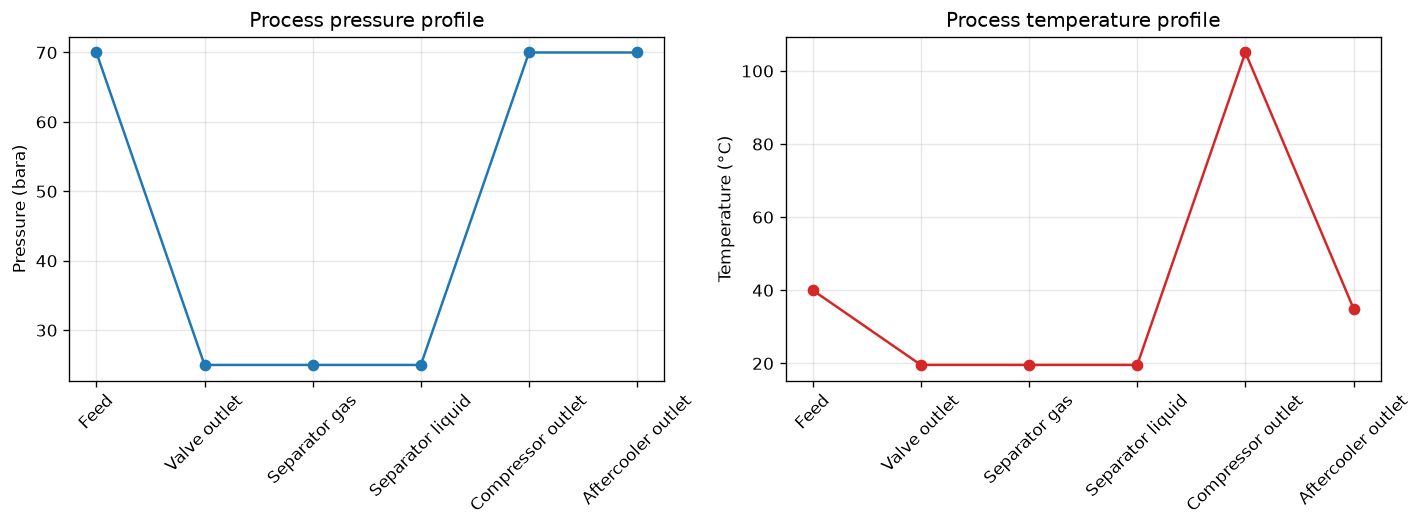

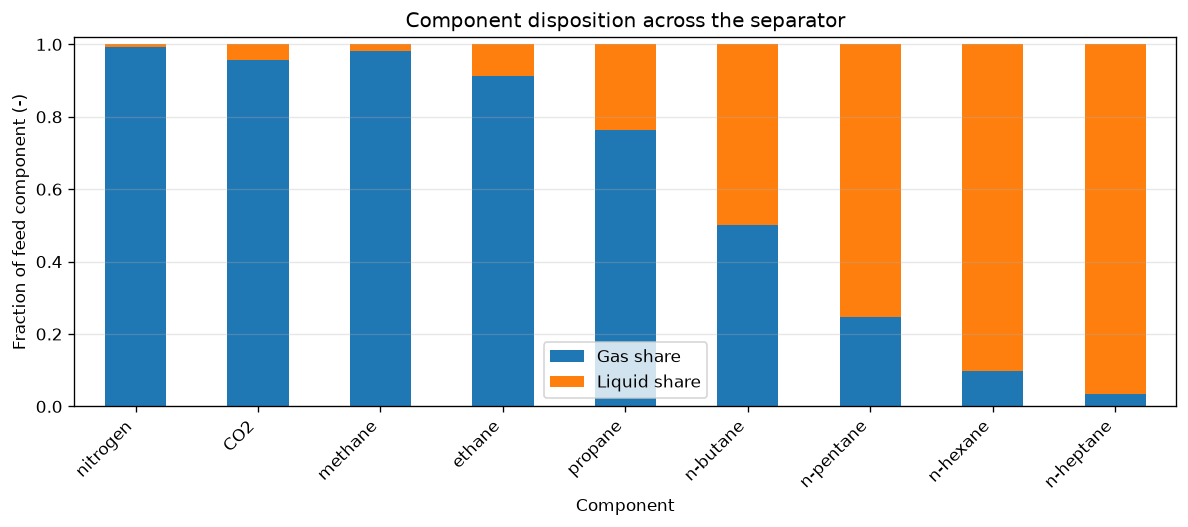

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    state_table["State"],
    state_table["Pressure (bara)"],
    marker="o",
    label="Pressure",
)
axes[0].set_ylabel("Pressure (bara)")
axes[0].set_title("Process pressure profile")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)

axes[1].plot(
    state_table["State"],
    state_table["Temperature (°C)"],
    marker="o",
    color="tab:red",
    label="Temperature",
)
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Process temperature profile")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

figure.tight_layout()
plt.show()

phase_fraction_table = component_balance_table.copy()
phase_fraction_table["Gas share"] = (
    phase_fraction_table["Gas amount"] / phase_fraction_table["Feed amount"]
)
phase_fraction_table["Liquid share"] = (
    phase_fraction_table["Liquid amount"] / phase_fraction_table["Feed amount"]
)

phase_fraction_table.plot(
    x="Component",
    y=["Gas share", "Liquid share"],
    kind="bar",
    stacked=True,
    figsize=(10, 4.5),
    color=["tab:blue", "tab:orange"],
)
plt.ylabel("Fraction of feed component (-)")
plt.title("Component disposition across the separator")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.0, 1.02)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Throughput sensitivity

Thermodynamic split fractions remain almost constant when only total feed rate changes in
this equilibrium, fixed-pressure model. Compressor power and cooler duty should therefore
scale monotonically with throughput. Real equipment curves, pressure losses, control limits,
and heat-transfer constraints would introduce nonlinear behavior.

In [14]:
rate_factors = np.array([0.50, 0.75, 1.00, 1.25, 1.50])
sensitivity_rows = []

for rate_factor in rate_factors:
    scenario_rate_kg_h = BASE_FEED_KG_H * rate_factor
    scenario = build_process(scenario_rate_kg_h)
    scenario_gas = scenario["separator"].getGasOutStream()
    scenario_liquid = scenario["separator"].getLiquidOutStream()
    scenario_mass_residual = (
        scenario_rate_kg_h
        - scenario_gas.getFlowRate("kg/hr")
        - scenario_liquid.getFlowRate("kg/hr")
    )
    sensitivity_rows.append(
        {
            "Rate factor": rate_factor,
            "Feed rate (kg/h)": scenario_rate_kg_h,
            "Gas recovery (-)": (
                scenario_gas.getFlowRate("kg/hr") / scenario_rate_kg_h
            ),
            "Compressor power (kW)": (
                scenario["compressor"].getPower("W") / 1_000.0
            ),
            "Cooling removed (kW)": (
                -scenario["aftercooler"].getDuty() / 1_000.0
            ),
            "Mass residual (kg/h)": scenario_mass_residual,
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table.round(6))

   Rate factor  Feed rate (kg/h)  ...  Cooling removed (kW)  Mass residual (kg/h)
0         0.50           10000.0  ...            379.884262                  -0.0
1         0.75           15000.0  ...            569.826393                  -0.0
2         1.00           20000.0  ...            759.768524                  -0.0
3         1.25           25000.0  ...            949.710655                   0.0
4         1.50           30000.0  ...           1139.652786                  -0.0

[5 rows x 6 columns]


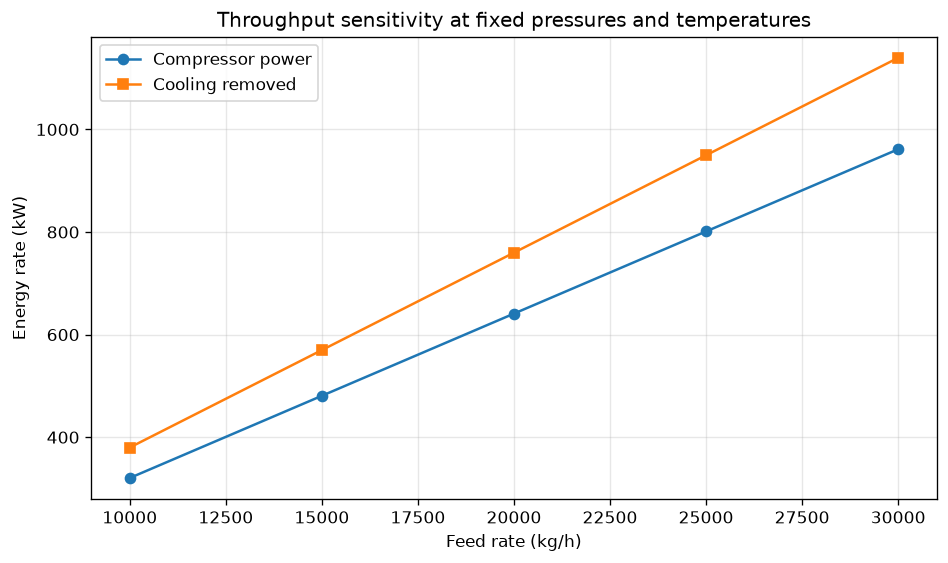

In [15]:
figure, axis = plt.subplots(figsize=(8, 4.8))
axis.plot(
    sensitivity_table["Feed rate (kg/h)"],
    sensitivity_table["Compressor power (kW)"],
    marker="o",
    label="Compressor power",
)
axis.plot(
    sensitivity_table["Feed rate (kg/h)"],
    sensitivity_table["Cooling removed (kW)"],
    marker="s",
    label="Cooling removed",
)
axis.set_xlabel("Feed rate (kg/h)")
axis.set_ylabel("Energy rate (kW)")
axis.set_title("Throughput sensitivity at fixed pressures and temperatures")
axis.grid(alpha=0.3)
axis.legend()
figure.tight_layout()
plt.show()

## Focused validation

The following checks are executable acceptance criteria, not visual suggestions. They cover
input normalization, convergence evidence, phase behavior, conservation, energy signs,
conversion identities, JSON integrity, global-unit restoration, and expected sensitivity
trends.

In [16]:
validation_checks = {
    "composition sums to unity": abs(sum(FEED_COMPOSITION.values()) - 1.0) < 1.0e-12,
    "all base states are finite": np.isfinite(
        state_table[["Mass rate (kg/h)", "Temperature (°C)", "Pressure (bara)"]]
    ).all().all(),
    "valve reaches separator pressure": abs(
        valve.getOutletStream().getPressure("bara") - SEPARATOR_PRESSURE_BARA
    ) < 1.0e-8,
    "valve cools the feed": (
        valve.getOutletStream().getTemperature("C")
        < feed.getTemperature("C")
    ),
    "separator produces gas": separator.getGasOutStream().getFlowRate("kg/hr") > 0.0,
    "separator produces liquid": (
        separator.getLiquidOutStream().getFlowRate("kg/hr") > 0.0
    ),
    "separator mass balance closes": abs(separator_mass_residual_kg_h) < 1.0e-8,
    "separator component balances close": maximum_component_residual < 1.0e-9,
    "valve enthalpy balance closes": abs(valve_enthalpy_residual_j) < 1.0e-2,
    "compressor reaches export pressure": abs(
        compressor.getOutletStream().getPressure("bara") - EXPORT_PRESSURE_BARA
    ) < 1.0e-8,
    "compressor power is positive": compressor_power_w > 0.0,
    "compressor raises temperature": (
        compressor.getOutletStream().getTemperature("C")
        > separator.getGasOutStream().getTemperature("C")
    ),
    "compressor energy identity closes": abs(compressor_energy_residual_w) < 1.0e-3,
    "aftercooler reaches target temperature": abs(
        aftercooler.getOutletStream().getTemperature("C")
        - AFTERCOOLER_TEMPERATURE_C
    ) < 1.0e-8,
    "aftercooler duty removes heat": cooler_duty_w < 0.0,
    "aftercooler energy identity closes": abs(cooler_energy_residual_w) < 1.0e-3,
    "equipment keys match across reports": equipment_sets_match,
    "all reports contain every process unit": len(default_report) == 5,
    "all report numeric values are finite": reports_are_finite,
    "canonical JSON round trip is identical": round_trip_report == default_report,
    "temperature conversions agree": conversion_table.iloc[:2][
        "Absolute residual"
    ].max() < 1.0e-8,
    "pressure conversions agree": conversion_table.iloc[2:4][
        "Absolute residual"
    ].max() < 1.0e-3,
    "mass and duty conversions agree": conversion_table.iloc[4:][
        "Absolute residual"
    ].max() < 1.0e-2,
    "report generation does not change state": np.allclose(
        state_before_reports,
        state_after_reports,
        rtol=0.0,
        atol=1.0e-10,
    ),
    "default unit profile is restored": Units.getSymbol("temperature") == "C",
    "sensitivity mass balances close": sensitivity_table[
        "Mass residual (kg/h)"
    ].abs().max() < 1.0e-8,
    "compressor power increases with feed rate": sensitivity_table[
        "Compressor power (kW)"
    ].is_monotonic_increasing,
    "cooling load increases with feed rate": sensitivity_table[
        "Cooling removed (kW)"
    ].is_monotonic_increasing,
    "gas recovery is rate independent": sensitivity_table[
        "Gas recovery (-)"
    ].max() - sensitivity_table["Gas recovery (-)"].min() < 1.0e-10,
}

validation_table = pd.DataFrame(
    {
        "Check": list(validation_checks),
        "Passed": list(validation_checks.values()),
    }
)
display(validation_table)
assert all(validation_checks.values())
print(f"All {len(validation_checks)} engineering checks passed.")

                                        Check  Passed
0                   composition sums to unity    True
1                  all base states are finite    True
2            valve reaches separator pressure    True
3                        valve cools the feed    True
4                      separator produces gas    True
5                   separator produces liquid    True
6               separator mass balance closes    True
7          separator component balances close    True
8               valve enthalpy balance closes    True
9          compressor reaches export pressure    True
10               compressor power is positive    True
11              compressor raises temperature    True
12          compressor energy identity closes    True
13     aftercooler reaches target temperature    True
14              aftercooler duty removes heat    True
15         aftercooler energy identity closes    True
16        equipment keys match across reports    True
17     all reports contain e

## Engineering interpretation

The base separator recovers most mass as gas while directing progressively more heavy
hydrocarbon to liquid. Recompression and aftercooling dominate the utility requirements.
Report unit changes preserve the process state and independently reproduce standard
conversions. The compact equipment report is therefore suitable for dashboards and status
exchange when consumers respect each field's explicit unit and tolerate equipment-specific
schemas.

For durable process reconstruction, configuration exchange, or E300-characterized fluids,
use the richer `ProcessSystem.toJson()` workflow rather than treating a status report as a
model definition.

## Limitations and applicability

- The separator is an equilibrium stage with no residence-time, entrainment, or level model.
- The valve neglects kinetic energy, acoustic effects, and detailed control-valve sizing.
- The compressor uses fixed isentropic efficiency; no map, surge, stonewall, or driver limit
  is included.
- The aftercooler has a specified outlet temperature, not a rated $UA$ or cooling-medium
  model.
- `Units` is global mutable state. Concurrent applications need synchronization or isolated
  workers around unit switching.
- Equipment report coverage depends on each unit's `toJson` implementation. Validate schemas
  before integrating them into a strict external contract.

## References and exercises

**Current NeqSim references**

- [Process simulation package](https://equinor.github.io/neqsim/process/README.html)
- [Process JSON export and E300 fluid characterization](https://github.com/equinor/neqsim/blob/master/docs/process/process_json_export_and_e300_fluids.md)
- [Thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim Python package](https://pypi.org/project/neqsim/)

**Suggested exercises**

1. Replace the fixed-efficiency compressor with a map and add surge-margin report fields.
2. Add a three-phase separator with water and validate aqueous component closure.
3. Export the live `ProcessSystem` configuration with `toJson()` and compare its purpose and
   schema with the equipment status report used here.
4. Wrap unit switching in a service-level lock and test concurrent report requests.